<a href="https://colab.research.google.com/github/AseelTariq/customer_churn_classification/blob/main/project_pattern_recognition_final_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Machine Learning Approaches for Customer Churn Classification**

**Read and display data**

In [ ]:
import pandas as pd
Bank_Customer_Churn_Dataset = pd.read_csv("/content/Bank Customer Churn Dataset.csv") #read data

In [ ]:
# Display the shape of the dataset: (number of rows, number of columns)
Bank_Customer_Churn_Dataset.shape

(10000, 14)

In [ ]:
# Display the first 10 rows of the dataset before preprocessing
Bank_Customer_Churn_Dataset.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
# Display descriptive statistics for all columns (numeric + categorical)
print("Descriptive statistics for the Bank Customer Churn dataset:\n")
Bank_Customer_Churn_Dataset.describe(include="all")

Descriptive statistics for the Bank Customer Churn dataset:



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [ ]:
# Check whether each row has a unique index (helps identify duplicated or misaligned rows)
print("is the index unique?", Bank_Customer_Churn_Dataset.index.is_unique)

is the index unique? True


In [ ]:
# Print the total number of elements in the DataFrame
# (calculated as rows × columns, not the number of rows)
print("size of data:", Bank_Customer_Churn_Dataset.size)

size of data: 140000


**Check Missing value and Duplicates**

In [ ]:
print(Bank_Customer_Churn_Dataset.isnull().sum())
#No missing values detected

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
Bank_Customer_Churn_Dataset.duplicated().sum()
#No duplicates values detected

np.int64(0)

In [ ]:
# Remove the 'RowNumber','CustomerId','Surname' columns permanently from the dataset
# We drop it because it does not contribute any useful information for prediction
Bank_Customer_Churn_Dataset.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [ ]:
# Display the first 10 rows after check duplicates and handling missing values and Drop unnecessary columns
Bank_Customer_Churn_Dataset.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
# Print the shape of the dataset after removing duplicates and handling missing values and Drop unnecessary columns
print("Data shape after handling duplicates and missing values:", Bank_Customer_Churn_Dataset.shape)

Data shape after handling duplicates and missing values: (10000, 11)


## **LightGBM**

**Preprocessing**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
encoder = LabelEncoder()

# Encode binary column Gender
Bank_Customer_Churn_Dataset['Gender'] = encoder.fit_transform(Bank_Customer_Churn_Dataset['Gender'])
# Female -> 0, Male -> 1

# Encode multi-category column Geography
Bank_Customer_Churn_Dataset['Geography'] = encoder.fit_transform(Bank_Customer_Churn_Dataset['Geography'])
# France -> 0, Germany -> 1, Spain -> 2


In [ ]:
# Display the first rows of the dataset after applying LabelEncoder
# on the categorical features (Gender, Geography)
Bank_Customer_Churn_Dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


LabelEncoder was used to convert categorical variables such as Gender and Geography into numerical values. LightGBM handles label-encoded categorical features efficiently without needing One-Hot Encoding, which reduces dimensionality and improves training speed and model performance. This makes LabelEncoding a suitable and optimized choice for LightGBM models."

In [ ]:
# Import the function used to split the data
from sklearn.model_selection import train_test_split

# Separate the dataset into features (X) and label (y)
X = Bank_Customer_Churn_Dataset.drop("Exited", axis=1)  # Remove the target column to get the features
y = Bank_Customer_Churn_Dataset["Exited"]               # Target column we want to predict

# Split the data into training and testing sets
# test_size=0.2 → 20% for testing, 80% for training
# random_state=1 → ensures the split is reproducible
# stratify=y → keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Print the shapes of the resulting datasets
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (8000, 10) X_test: (2000, 10)
y_train: (8000,) y_test: (2000,)


we split the data into X and y so the model knows what features to learn from and what output to predict. Then we used train_test_split to separate the data into training and testing sets. This helps us train the model on one part of the data and then test it on new data to see how well it performs. we chose test_size=0.2 to keep 20% for testing, random_state=1 to get the same split every time, and stratify=y to keep the class balance the same in both sets

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


<Axes: xlabel='Exited'>

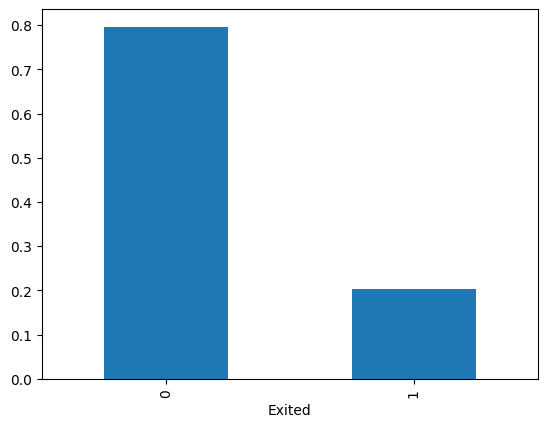

In [ ]:
# Print the percentage distribution of the target classes (Exited = 0 and 1)
# This shows the proportion of each class in the dataset
print(Bank_Customer_Churn_Dataset['Exited'].value_counts(normalize=True))

# Plot a bar chart to visualize the class distribution
# This helps us clearly see that the dataset is unbalanced (more class 0 than class 1)
Bank_Customer_Churn_Dataset['Exited'].value_counts(normalize=True).plot.bar()

checks and visualizes the class distribution of the target variable to detect imbalance, which is important because class imbalance can affect model performance.

**Training LightGMB Model on Training Data**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create the LightGBM model
model = LGBMClassifier(
    objective='binary',         # Binary classification: predict Exited or Not Exited
    learning_rate=0.1,          # Step size at each boosting iteration
    num_leaves=31,              # Maximum number of leaves per tree
    feature_fraction=0.8,       # Randomly select 80% of features per tree
    bagging_fraction=0.8,       # Randomly select 80% of data per iteration
    bagging_freq=5,             # Perform bagging every 5 iterations
    is_unbalance=True,          # Automatically handle class imbalance
    random_state=42             # Ensure reproducibility
)

model.fit(X_train, y_train)  # Train the model on training data

y_train_pred = model.predict(X_train) # Probabilities class labels (0 or 1)

acc = accuracy_score(y_train, y_train_pred)            # Calculate training accuracy
prec = precision_score(y_train, y_train_pred)          # Calculate training precision
rec = recall_score(y_train, y_train_pred)              # Calculate training recall
f1 = f1_score(y_train, y_train_pred)                   # Calculate training F1-score
y_train_prob = model.predict_proba(X_train)[:, 1]      # Calculate training ROC-AUC
roc_auc = roc_auc_score(y_train, y_train_prob)


print(f"Training Accuracy: {acc:.4f}")   # Print training accuracy
print(f"Training Precision: {prec:.4f}") # Print training precision
print(f"Training Recall: {rec:.4f}")     # Print training recall
print(f"Training F1-score: {f1:.4f}")    # Print training F1-score
print(f"Training ROC-AUC: {roc_auc:.4f}") # Print training ROC-AUC

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002831 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data point

builds and trains a LightGBM classifier with parameters optimized for binary classification and class imbalance. After training, it evaluates the model using key metrics such as accuracy, precision, recall, F1-score, and ROC-AUC to assess its performance and ensure the model is learning effectively.

**Testing LightGMB Model on Testing Data**

In [ ]:
# Predict on the test data
y_test_pred = model.predict(X_test)  # Predict class labels (0 or 1) directly for each sample

# Evaluate model performance on the test set
acc = accuracy_score(y_test, y_test_pred)         # Calculate overall accuracy
prec = precision_score(y_test, y_test_pred)       # Calculate precision: TP / (TP + FP)
rec = recall_score(y_test, y_test_pred)           # Calculate recall: TP / (TP + FN)
f1 = f1_score(y_test, y_test_pred)                # Calculate F1-score: harmonic mean of precision and recall
y_test_prob = model.predict_proba(X_test)[:, 1]   # Get probabilities for class 1
roc_auc = roc_auc_score(y_test, y_test_prob)      # Calculate ROC-AUC

print(f"Test Accuracy: {acc:.4f}")   # Print accuracy
print(f"Test Precision: {prec:.4f}") # Print precision
print(f"Test Recall: {rec:.4f}")     # Print recall
print(f"Test F1-score: {f1:.4f}")    # Print F1-score
print(f"Test ROC-AUC: {roc_auc:.4f}")# Print evaluation metrics

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Test Accuracy: 0.8015
Test Precision: 0.5091
Test Recall: 0.6904
Test F1-score: 0.5860
Test ROC-AUC: 0.8551


evaluates the trained LightGBM model on unseen test data using key performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. This step ensures that the model generalizes well and verifies its real-world predictive performance.

**Hyperparameter Tuning**

In [ ]:
# Step 1: Import libraries
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# Step 2: Define hyperparameter space
# get hyperparameter options and return the search space for tuning
param_distributions = {
    'num_leaves': [31, 50, 100, 200],
    'max_depth': [-1, 10, 20, 30],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Step 3: Create RandomizedSearchCV object
# get RandomizedSearchCV object and return a cross-validated search for best hyperparameters
random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,          # number of parameter settings sampled
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Step 4: Fit RandomizedSearchCV on training data
# get trained RandomizedSearchCV object and return results of fitting on X_train, y_train
random_search.fit(X_train, y_train)

# Step 5: Get the best estimator
# get the best tuned LightGBM model and return as best_lgb
best_lgb = random_search.best_estimator_

# Make sure X_test has the same columns as X_train
X_test = X_test[X_train.columns]

# Step 6: Predict on test data
# get predictions from the tuned LightGBM model and return predicted labels for X_test
y_pred_best_lgb = best_lgb.predict(X_test)

# Step 7: Evaluate performance
# get weighted F1 score on test data and return to assess model performance
print("LightGBM Test F1:", f1_score(y_test, y_pred_best_lgb, average='weighted'))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
LightGBM Test F1: 0.8525899947862454


"RandomizedSearchCV is used because it efficiently searches a wide hyperparameter space in less time than GridSearchCV. Instead of testing every possible combination, it samples a fixed number of random combinations, allowing LightGBM to be tuned faster while still finding high-quality hyperparameters. This makes it ideal when the model has many parameters and the dataset is large.

In [ ]:
# Import evaluation metrics from scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict class labels for X_test (0 or 1)
y_pred = best_lgb.predict(X_test)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)                       # Overall accuracy: fraction of correctly predicted samples
prec = precision_score(y_test, y_pred, average='weighted') # Weighted precision: fraction of correct positive predictions, weighted by class support
rec = recall_score(y_test, y_pred, average='weighted')     # Weighted recall: fraction of actual positives correctly predicted, weighted by class support
f1 = f1_score(y_test, y_pred, average='weighted')          # Weighted F1-score: harmonic mean of weighted precision and recall
y_test_prob = best_lgb.predict_proba(X_test)[:, 1]         # Predicted probabilities for the positive class (Exited=1), needed for ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_prob)               # ROC-AUC: ability of the model to rank positives higher than negatives

# Print all evaluation metrics
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8670
Precision: 0.8605
Recall: 0.8670
F1-score: 0.8526
ROC-AUC: 0.8548


Class weights are used to handle imbalanced data, ensuring the model pays more attention to the minority class. This helps improve performance metrics like recall and F1-score for underrepresented classes, preventing the model from being biased toward the majority class.

In [ ]:
import pandas as pd

# Extract and display feature importance from the trained LightGBM model
# This shows which features contributed most to the model's predictions
importance_df = pd.DataFrame({
    'feature': best_lgb.feature_name_,       # List of feature names used by the model
    'importance': best_lgb.feature_importances_  # Corresponding feature importance scores
}).sort_values(by='importance', ascending=False)  # Sort features by importance (highest first)

print(importance_df)  # Print the sorted feature importance table


           feature  importance
5          Balance        5475
0      CreditScore        4187
9  EstimatedSalary        4091
3              Age        3699
6    NumOfProducts        1820
4           Tenure        1767
1        Geography        1525
2           Gender         817
8   IsActiveMember         805
7        HasCrCard         314


extracts and displays the feature importance from the trained LightGBM model. It helps understand which features contribute most to the predictions, guiding interpretation and potential feature selection.

**Visualizations**

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


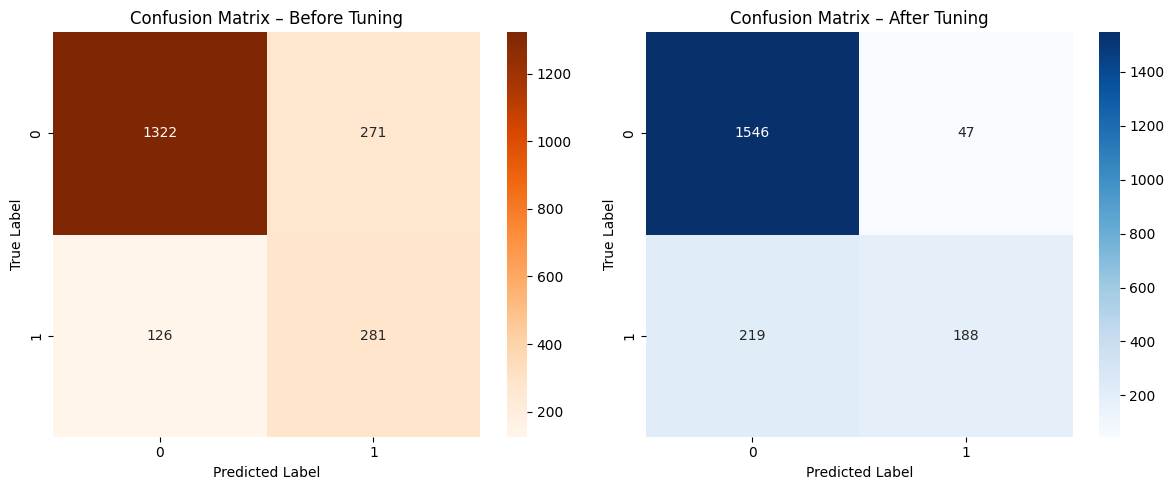

In [ ]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict class labels for test data
# Before tuning
y_test_pred_before = model.predict(X_test)

# After tuning
y_test_pred_after = best_lgb.predict(X_test)

# Compute confusion matrices
cm_before = confusion_matrix(y_test, y_test_pred_before)
cm_after  = confusion_matrix(y_test, y_test_pred_after)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before tuning
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Confusion Matrix – Before Tuning')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# After tuning
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix – After Tuning')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

The comparison shows that tuning improved class 0 predictions but made the model worse at detecting class 1, increasing missed positive cases.

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


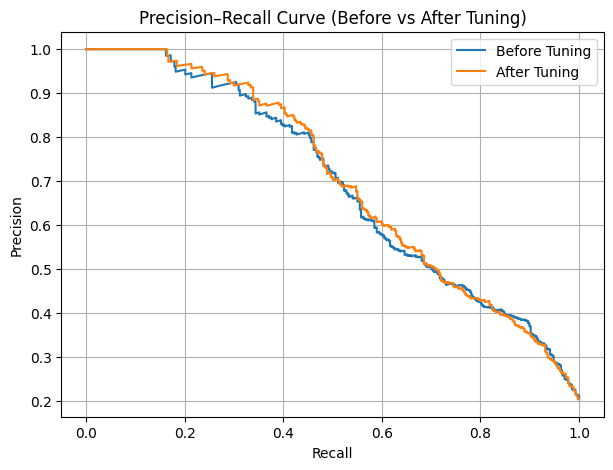

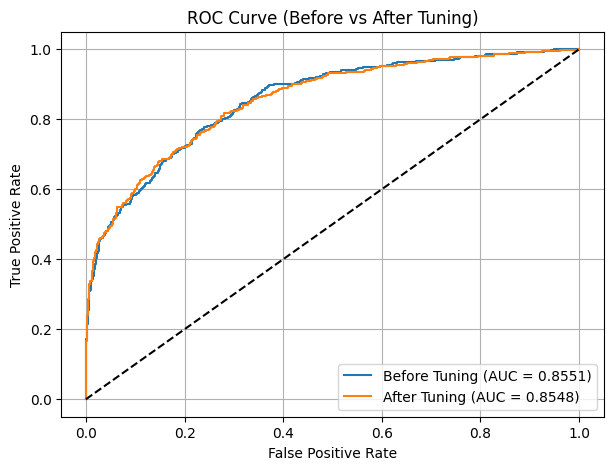

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, f1_score
import matplotlib.pyplot as plt

#   Get predicted probabilities for the positive class before and after tuning
y_prob_before = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (Exited=1) before tuning
y_prob_after = best_lgb.predict_proba(X_test)[:, 1]  # Probabilities after hyperparameter tuning

#   Precision–Recall Curve
# Compute precision and recall values for both models
precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after)

plt.figure(figsize=(7,5))
plt.plot(recall_before, precision_before, label="Before Tuning")
plt.plot(recall_after, precision_after, label="After Tuning")
plt.title('Precision–Recall Curve (Before vs After Tuning)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

#   ROC Curve
# Compute false positive rate (FPR) and true positive rate (TPR) for both models
fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_before)
fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_after)

# Calculate AUC for each model
auc_before = auc(fpr_before, tpr_before)
auc_after = auc(fpr_after, tpr_after)

plt.figure(figsize=(7,5))
plt.plot(fpr_before, tpr_before, label=f'Before Tuning (AUC = {auc_before:.4f})')
plt.plot(fpr_after, tpr_after, label=f'After Tuning (AUC = {auc_after:.4f})')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line representing random classifier
plt.title('ROC Curve (Before vs After Tuning)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

Both the Precision–Recall and ROC curves show that hyperparameter tuning resulted in only minor improvements. The model’s overall performance remained stable, with slightly better precision and smoother classification boundaries after tuning.

## **NB Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
Bank_Customer_Churn_Dataset = pd.read_csv("/content/Bank Customer Churn Dataset.csv") #read data

In [ ]:
# Remove the 'RowNumber','CustomerId','Surname' columns permanently from the dataset
# We drop it because it does not contribute any useful information for prediction
Bank_Customer_Churn_Dataset.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [ ]:
# get the count of each class in the target column and return it to check if the dataset is balanced
print(y.value_counts())

# get the proportion of each class in the target column and return it to assess class distribution
print(y.value_counts(normalize=True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


checks whether the target classes are balanced. The first line shows how many samples are in each class, and the second line shows their proportions. This helps us understand if one class is much larger than the other.

In [ ]:
# Import the function used to split the data
from sklearn.model_selection import train_test_split

# Separate the dataset into features (X) and label (y)
X = Bank_Customer_Churn_Dataset.drop("Exited", axis=1)  # Remove the target column to get the features
y = Bank_Customer_Churn_Dataset["Exited"]               # Target column we want to predict

# Split the data into training and testing sets
# test_size=0.2 → 20% for testing, 80% for training
# random_state=1 → ensures the split is reproducible
# stratify=y → keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Print the shapes of the resulting datasets
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (8000, 10) X_test: (2000, 10)
y_train: (8000,) y_test: (2000,)


we split the data into X and y so the model knows what features to learn from and what output to predict. Then we used train_test_split to separate the data into training and testing sets. This helps us train the model on one part of the data and then test it on new data to see how well it performs. we chose test_size=0.2 to keep 20% for testing, random_state=1 to get the same split every time, and stratify=y to keep the class balance the same in both sets

In [ ]:
# Apply One-Hot Encoding to convert categorical features into numeric binary columns
categorical_cols = ['Geography', 'Gender']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align test set columns with training set to ensure both have the same features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

We used One-Hot Encoding to convert categorical text columns into numeric 0/1 columns. It treats each category independently without implying any order, which prevents misleading relationships and works well with models like Naive Bayes and KNN .

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [ ]:
nb_before = GaussianNB()
nb_before.fit(X_train_s, y_train)

y_pred_before = nb_before.predict(X_test_s)
y_prob_before = nb_before.predict_proba(X_test_s)[:, 1]


In [ ]:
from imblearn.over_sampling import SMOTE

# get SMOTE instance and return an object to perform oversampling on the training data
smote = SMOTE(random_state=42)

# get resampled training data and return X_res and y_res with balanced classes
X_res, y_res = smote.fit_resample(X_train, y_train)

# get the count of each class after SMOTE and return to check the new class distribution
print("Counts after SMOTE:")
print(y_res.value_counts())

# get the proportion of each class after SMOTE and return to verify balanced distribution
print("Proportions after SMOTE:")
print(y_res.value_counts(normalize=True))

Counts after SMOTE:
Exited
0    6370
1    6370
Name: count, dtype: int64
Proportions after SMOTE:
Exited
0    0.5
1    0.5
Name: proportion, dtype: float64


We used SMOTE to balance the classes and help the model learn the minority class better

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

X_res_s = scaler.fit_transform(X_res)
X_test_s = scaler.transform(X_test)


In [ ]:
nb_after = GaussianNB()
nb_after.fit(X_res_s, y_res)

y_pred_after = nb_after.predict(X_test_s)
y_prob_after = nb_after.predict_proba(X_test_s)[:, 1]


Used NB to compare its performance with LightGBM

We used this line to get Naive Bayes predictions for evaluating and comparing with LightGBM

In [ ]:
print("Before SMOTE Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Before SMOTE F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))
print("Before SMOTE Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Before SMOTE Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("Before SMOTE ROC-AUC:", roc_auc_score(y_test, y_proba_nb))


Before SMOTE Accuracy: 0.6905
Before SMOTE F1 Score: 0.7186086235797153
Before SMOTE Precision: 0.7902920029424128
Before SMOTE Recall: 0.6905
Before SMOTE ROC-AUC: 0.758157232733504


Accuracy: Used to measure the overall correctness of the Naive Bayes model and see how many predictions were right.

F1 Score (Weighted): Used because it balances precision and recall, especially when classes are not evenly distributed.

Precision (Weighted): Used to check how many of the predicted positives were actually correct, considering all classes.

Recall (Weighted): Used to measure how well the model identifies actual positive cases across all classes.

Confusion Matrix: Used to visualize correct vs. incorrect predictions for each class.

Hmapeat: Used to display the confusion matrix clearly and make interpretation easier.



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

#  1) Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#  2) PCA

pca = PCA(n_components=10) # Changed n_components from 20 to 10, as the maximum number of features is 11
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)

# 3) Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train_p, y_train)

#  4) Predictions
y_pred = nb.predict(X_test_p)
y_proba = nb.predict_proba(X_test_p)[:, 1]

# 5) Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8215
F1 Score: 0.780744571140081
Precision: 0.8038078484261246
Recall: 0.8215
ROC-AUC: 0.7898098406572983


This pipeline standardizes the features with StandardScaler and applies PCA to reduce dimensionality and remove noise. Gaussian Naive Bayes is then trained on the processed features, and the model is evaluated using Accuracy, F1 Score, Precision, Recall, and ROC-AUC to measure performance.

In [ ]:
# Check Overfitting / Underfitting
# Predictions on training data
train_pred = nb.predict(X_train_p)  # Use the Naive Bayes model (nb) and its prepared training data (X_train_p)

# Weighted F1 on training data
print("Train F1:", f1_score(y_train, train_pred, average='weighted'))

# Weighted F1 on test data
print("Test F1:", f1_score(y_test, y_pred, average='weighted'))

Train F1: 0.7744087318745144
Test F1: 0.780744571140081


Compared F1 scores on training and test sets to detect overfitting or underfitting; small difference indicates good generalization

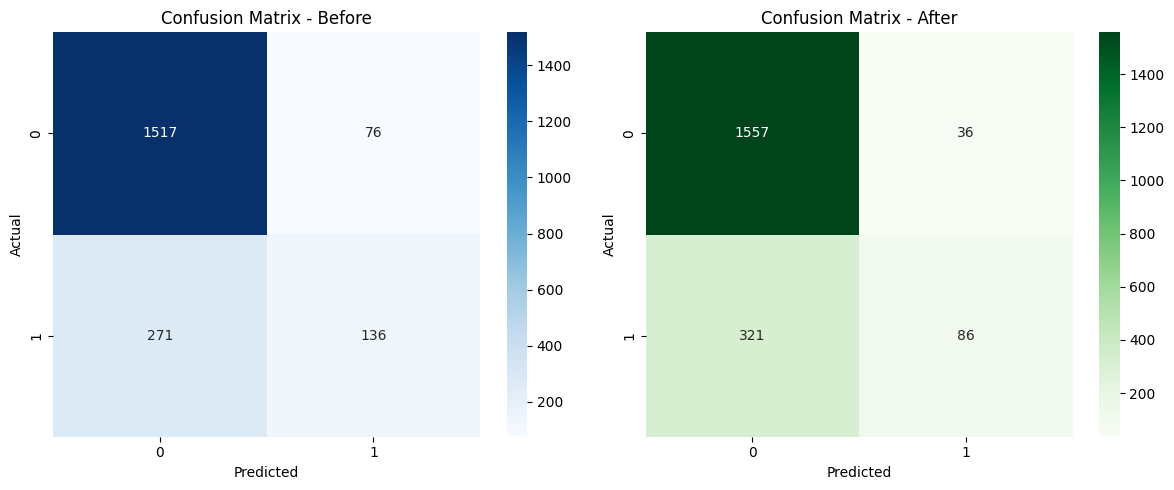

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_before = confusion_matrix(y_test, y_pred_before)   # Old model (before tuning), fixed to use binary predictions
cm_after = confusion_matrix(y_test, y_pred)       # New model (after replacement/tuning)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix before
sns.heatmap(cm_before, annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Before")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Plot confusion matrix after
sns.heatmap(cm_after, annot=True, fmt='d', cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix - After")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

The comparison between the confusion matrices before and after tuning shows that the Naive Bayes model did improve after tuning

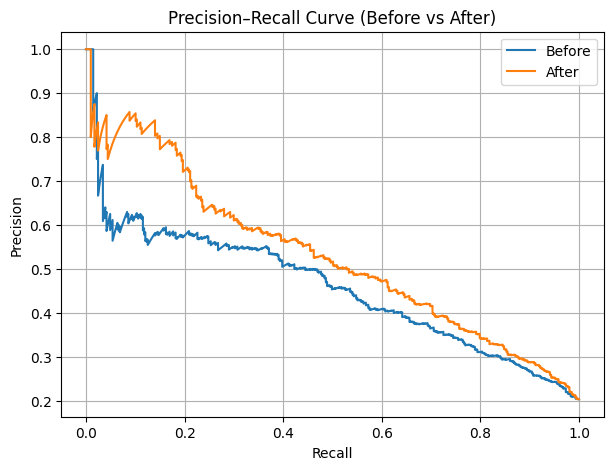

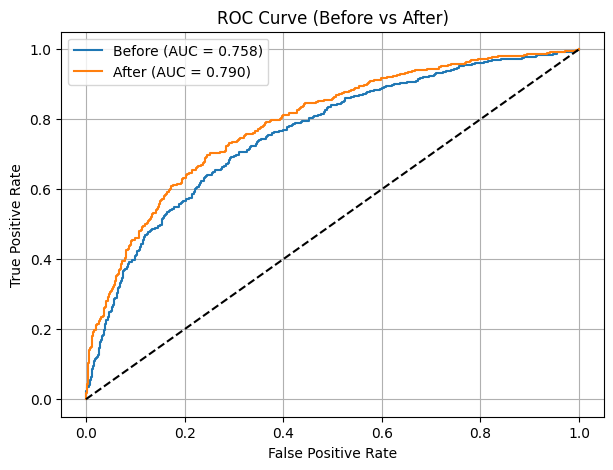

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt


# Probabilities for class 1 (Churn)

y_prob_before = y_proba_nb        # Old model (before tuning)
y_prob_after  = y_proba          # New model (after replacement/tuning)

# Precision–Recall Curve

precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after)

plt.figure(figsize=(7,5))
plt.plot(recall_before, precision_before, label="Before")
plt.plot(recall_after, precision_after, label="After")
plt.title('Precision–Recall Curve (Before vs After)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


# ROC Curve

fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_before)
fpr_after, tpr_after, _   = roc_curve(y_test, y_prob_after)

auc_before = auc(fpr_before, tpr_before)
auc_after  = auc(fpr_after, tpr_after)

plt.figure(figsize=(7,5))
plt.plot(fpr_before, tpr_before, label=f'Before (AUC = {auc_before:.3f})')
plt.plot(fpr_after, tpr_after, label=f'After (AUC = {auc_after:.3f})')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.title('ROC Curve (Before vs After)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

The results show that the tuning process did lead to a significant improvement in performance.

## **KNN**

In [ ]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
Bank_Customer_Churn_Dataset = pd.read_csv("/content/Bank Customer Churn Dataset.csv")

Bank_Customer_Churn_Dataset.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)


In [ ]:
#  CHECK TARGET BALANCE BEFORE SPLIT

print("Class counts:\n", Bank_Customer_Churn_Dataset["Exited"].value_counts())
print("\nClass proportions:\n", Bank_Customer_Churn_Dataset["Exited"].value_counts(normalize=True))

Class counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64

Class proportions:
 Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [ ]:
# ONE-HOT ENCODING
Bank_Customer_Churn_Dataset = pd.get_dummies(
    Bank_Customer_Churn_Dataset,
    columns=['Geography', 'Gender'],
    drop_first=True
)

print("Dataset shape after One-Hot:", Bank_Customer_Churn_Dataset.shape)

Dataset shape after One-Hot: (10000, 12)


We used One-Hot Encoding to convert categorical text columns into numeric 0/1 columns. It treats each category independently without implying any order, which prevents misleading relationships and works well with models like Naive Bayes and KNN .

In [ ]:
# SPLITTING THE DATA INTO TRAIN AND TEST SETS

from sklearn.model_selection import train_test_split

# Separate the dataset into features (X) and label (y)
X = Bank_Customer_Churn_Dataset.drop("Exited", axis=1)  # Remove the target column to get the features
y = Bank_Customer_Churn_Dataset["Exited"]               # Target column we want to predict

# Split the data into training and testing sets
# test_size=0.2 → 20% for testing, 80% for training
# random_state=1 → ensures the split is reproducible
# stratify=y → keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Print the shapes of the resulting datasets
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (8000, 11) X_test: (2000, 11)
y_train: (8000,) y_test: (2000,)


In [ ]:
# BALANCING THE DATA WITH SMOTE (for KNN)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape, y_train.value_counts())

After SMOTE: (12740, 11) Exited
0    6370
1    6370
Name: count, dtype: int64


We used SMOTE to balance the classes and help the model learn the minority class better

In [ ]:
# FEATURE SCALING (Important for KNN)

scaler = StandardScaler() # Z-Score
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
scaled_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.558915,3.498521,1.541746,0.857998,-0.733343,0.782334,1.291968,-1.513747,-0.75289,1.563088,-1.226750
1,-0.363090,0.800672,-1.396176,-1.326240,1.005174,0.782334,-0.774013,1.589964,-0.75289,-0.639759,0.815162
2,-2.201670,2.099636,-1.396176,-0.282698,-0.733343,0.782334,1.291968,-0.419308,-0.75289,1.563088,0.815162
3,-1.124632,-0.098611,0.807266,-1.326240,-0.733343,-1.278227,1.291968,1.046099,-0.75289,-0.639759,-1.226750
4,1.072960,-0.398371,-1.028936,-1.326240,1.005174,0.782334,-0.774013,0.735999,-0.75289,-0.639759,0.815162


We used StandardScaler or Z-Score to make all numeric features in the same range. This helps KNN compare distances fairly and prevents any feature from having a bigger effect than others.

In [ ]:
# TRAIN MODEL (KNN)

from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier (k=5 is a standard baseline)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
knn_pred = knn_model.predict(X_test_scaled)

# Show sample predictions
print("KNN predictions:", knn_pred[:10])

KNN predictions: [0 0 0 0 1 1 0 0 0 0]


In [ ]:
# MODEL EVALUATION (KNN)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# Compute evaluation metrics

# predicted labels
y_pred_before = knn_model.predict(X_test_scaled)

# predicted probabilities
knn_probs_before = knn_model.predict_proba(X_test_scaled)[:, 1]

# AUC before tuning
auc_before = roc_auc_score(y_test, knn_probs_before)
print(" KNN Evaluation Metrics :")
print("Accuracy:", accuracy_score(y_test, y_pred_before))
print("F1:", f1_score(y_test, y_pred_before, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_before, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_before, average='weighted'))
print("ROC-AUC:", auc_before)

 KNN Evaluation Metrics :
Accuracy: 0.7745
F1: 0.7866517664531928
Precision: 0.8078397321428572
Recall: 0.7745
ROC-AUC: 0.7862500404873286


In [ ]:
# GRIDSEARCHCV — HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV
params = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=3,
    scoring="f1_weighted"
)

grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

print("Best KNN Model:", best_knn)

Best KNN Model: KNeighborsClassifier(metric='manhattan', n_neighbors=11, weights='distance')


Tuned n_neighbors,weights,metric to improve performance by handling features with very small variance; GridSearchCV finds the best value.

We used GridSearchCV to tune KNN hyperparameters (number of neighbors, distance metric, and weighting method) to find the best configuration that maximizes the F1 score.

In [ ]:
#  EVALUATION AFTER TUNING

# Predictions
y_pred_best = best_knn.predict(X_test_scaled)
y_pred_probs_best = best_knn.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned F1:", f1_score(y_test, y_pred_best, average='weighted'))
print("Tuned Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Tuned Recall:", recall_score(y_test, y_pred_best, average='weighted'))

# AUC
knn_auc = roc_auc_score(y_test, y_pred_probs_best)
print("Tuned ROC-AUC:", knn_auc)

Tuned Accuracy: 0.786
Tuned F1: 0.7964265695594229
Tuned Precision: 0.8140498556350475
Tuned Recall: 0.786
Tuned ROC-AUC: 0.8018889459567425


Tuned model achieved better performance after hyperparameter tuning.

In [ ]:
#  OVERFITTING / UNDERFITTING CHECK

train_pred_knn = best_knn.predict(X_train_scaled)

print("Train F1:", f1_score(y_train, train_pred_knn, average="weighted"))
print("Test F1 :", f1_score(y_test, y_pred_best, average="weighted"))

Train F1: 1.0
Test F1 : 0.7964265695594229


KNN showed signs of overfitting. The F1-score on the training data was 1.0, while the test F1-score dropped to 0.798. This indicates that the model memorized the training samples, especially after applying SMOTE, which increases sample density around minority points.


Methods to Reduce Overfitting in KNN :

1) Increase the number of neighbors (k)

2) Use “uniform” weights instead of “distance”



In [ ]:
# REDUCE OVERFITTING - NEW TUNING
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    "n_neighbors": [7, 9, 11, 13, 15, 17],   # increase k
    "weights": ["uniform"],                 # Use “uniform”
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

print("Best KNN Model:", best_knn)

Best KNN Model: KNeighborsClassifier(metric='manhattan', n_neighbors=13)


In [ ]:
# Predictions
y_pred_best = best_knn.predict(X_test_scaled)
# evaluat after reduce overfitting
y_pred_probs_best = best_knn.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned F1:", f1_score(y_test, y_pred_best, average='weighted'))
print("Tuned Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Tuned Recall:", recall_score(y_test, y_pred_best, average='weighted'))

# AUC
knn_auc = roc_auc_score(y_test, y_pred_probs_best)
print("Tuned ROC-AUC:", knn_auc)

Tuned Accuracy: 0.785
Tuned F1: 0.7953536345776032
Tuned Precision: 0.8126771571051419
Tuned Recall: 0.785
Tuned ROC-AUC: 0.8002640545013426


In [ ]:
train_pred_knn = best_knn.predict(X_train_scaled)

print("Train F1:", f1_score(y_train, train_pred_knn, average='weighted'))
print("Test F1 :", f1_score(y_test, y_pred_best, average='weighted'))

Train F1: 0.8497602409952113
Test F1 : 0.7953536345776032


After tuning the KNN model, the overfitting issue was clearly reduced. The difference between the training and testing F1-scores became much smaller, the model now generalizes better and performs more consistently on new data.

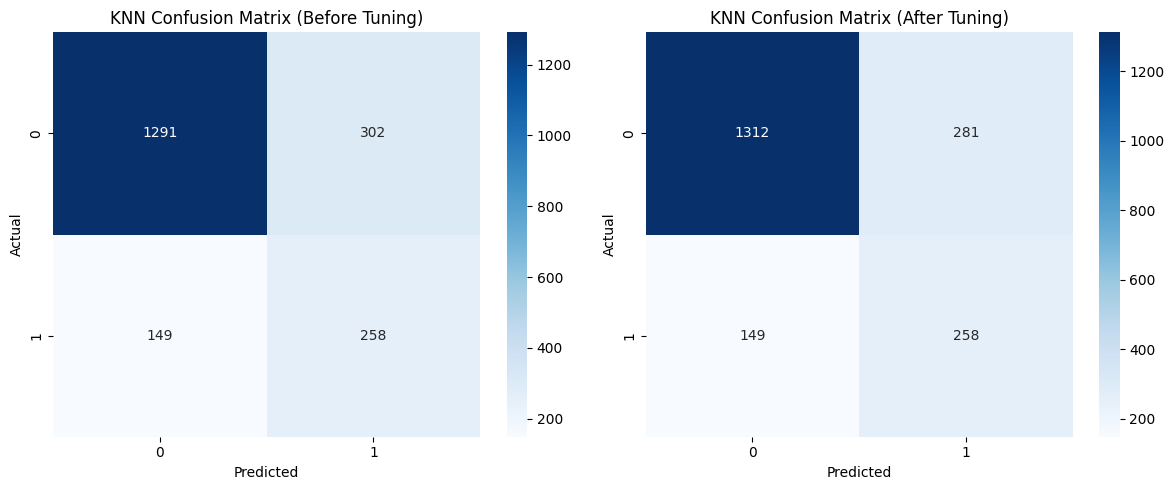

In [ ]:
# CONFUSION MATRIX (KNN)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_before = confusion_matrix(y_test, y_pred_before)
cm_after = confusion_matrix(y_test, y_pred_best)

# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix BEFORE tuning
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("KNN Confusion Matrix (Before Tuning)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix AFTER tuning
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("KNN Confusion Matrix (After Tuning)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


After tuning, the KNN model shows a noticeable improvement in predicting class 0, increasing true negatives and reducing false positives. Although the detection of class 1 remains unchanged, the reduction in misclassification rates demonstrates that tuning helped the model generalize better and make more accurate predictions overall

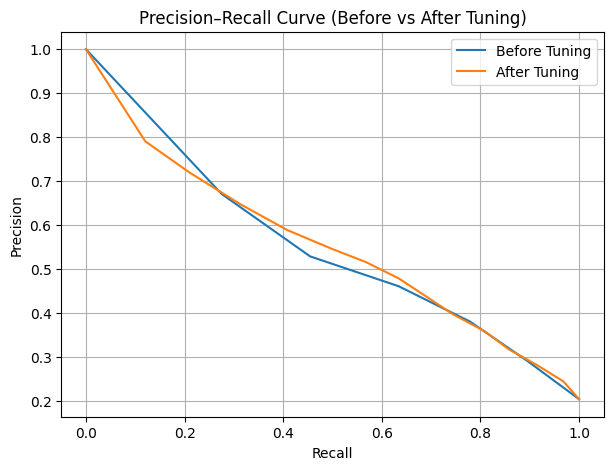

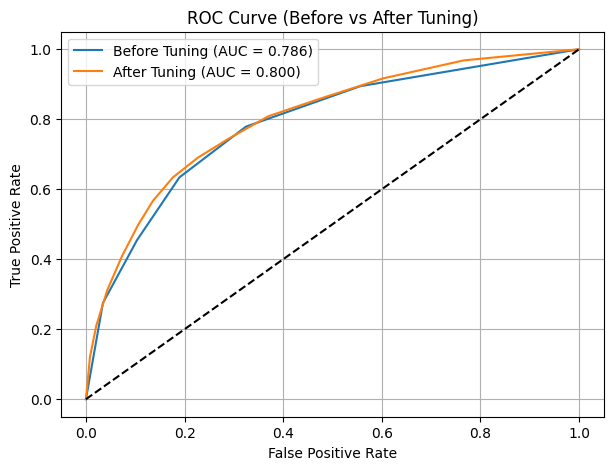

In [ ]:
# ROC CURVE (KNN)

from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_curve,
    f1_score, roc_curve, auc
)
import matplotlib.pyplot as plt

y_prob_before = knn_model.predict_proba(X_test_scaled)[:, 1]
y_prob_after  = best_knn.predict_proba(X_test_scaled)[:, 1]



# Precision–Recall Curve

precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after)

plt.figure(figsize=(7,5))
plt.plot(recall_before, precision_before, label="Before Tuning")
plt.plot(recall_after, precision_after, label="After Tuning")
plt.title('Precision–Recall Curve (Before vs After Tuning)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()



# ROC Curve

fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_before)
fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_after)

auc_before = auc(fpr_before, tpr_before)
auc_after = auc(fpr_after, tpr_after)

plt.figure(figsize=(7,5))
plt.plot(fpr_before, tpr_before, label=f'Before Tuning (AUC = {auc_before:.3f})')
plt.plot(fpr_after, tpr_after, label=f'After Tuning (AUC = {auc_after:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve (Before vs After Tuning)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

The ROC curve shows that the model improved after tuning.
The AUC increased slightly from 0.786 to 0.800, meaning the model became better at separating the two classes.
Both curves are clearly above the diagonal baseline, so the model is performing better than random guessing and is making more reliable predictions.

## **Comparing model Performance**

**tuned model performance results**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Performance results after tuning
results = {
    "Model": ["LightGBM", "Naive Bayes", "KNN"],
    "Accuracy": [0.8670, 0.8215, 0.7850],
    "Precision": [0.8605, 0.8038, 0.8127],
    "Recall": [0.8670, 0.8215, 0.7850],
    "F1-score": [0.8526, 0.7807, 0.7953],
    "ROC-AUC": [0.8548, 0.7898, 0.8003]
}

# Convert to DataFrame
results_models = pd.DataFrame(results)

**Comparison table**

In [ ]:
# Display comparison table
print(" Model Performance Comparison \n")
results_models

 Model Performance Comparison 



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM,0.8670,0.8605,0.8670,0.8526,0.8548
1,Naive Bayes,0.8215,0.8038,0.8215,0.7807,0.7898
2,KNN,0.7850,0.8127,0.7850,0.7953,0.8003


**plot comparison chart**

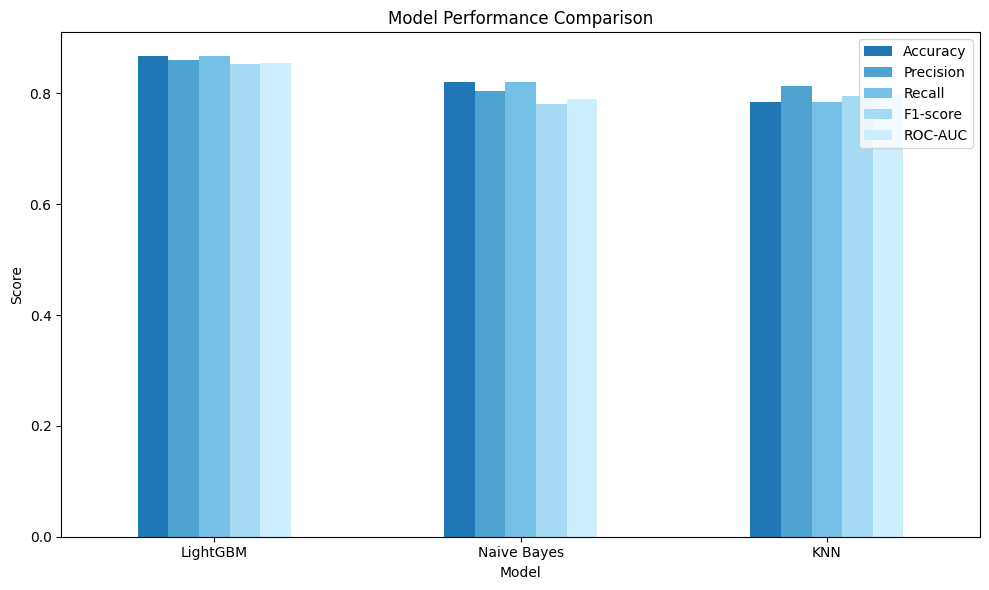

In [ ]:
# Plot performance comparison with blue palette
result_model_plot = results_models.set_index("Model")

# Custom blue color shades
blue_colors = ["#1f77b4", "#4fa3d1", "#77c0e5", "#a6daf3", "#cdeefd"]

result_model_plot.plot(kind="bar", figsize=(10, 6), color=blue_colors)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Generate insights**

In [ ]:
# Generate insights based on performance differences

def best(metric):
    return results_models.loc[results_models[metric].idxmax(), "Model"]

print("      Insights   \n")

print(f"- Highest Accuracy: {best('Accuracy')}")
print(f"- Best Precision: {best('Precision')}")
print(f"- Best Recall: {best('Recall')}")
print(f"- Best F1-score: {best('F1-score')}")
print(f"- Best ROC-AUC: {best('ROC-AUC')}\n")

print("Overall Insight:")
if best("Accuracy") == best("F1-score") == best("ROC-AUC"):
    print(f"{best('Accuracy')} dominates overall across the key metrics.")
else:
    print("Different models excel in different metrics — consider trade-offs.")

      Insights   

- Highest Accuracy: LightGBM
- Best Precision: LightGBM
- Best Recall: LightGBM
- Best F1-score: LightGBM
- Best ROC-AUC: LightGBM

Overall Insight:
LightGBM dominates overall across the key metrics.
